# ✨Evaluating spectral reflectance separability✨

This notebook can be used to evaluate spectral separability of point-source spectra using three methods: Hierarchical Cluster Analysis, Spectral Angle Classification, and Random Forest Classification.

## __________________________________________________________________________________________________________________________________________________________
##
## 🔨 Set-up 
Importing modules and data

In [1]:
# Import required scripts
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import preprocessing as prep
from scipy.cluster.hierarchy import fcluster, linkage
import peaks_analysis as pa
import stats.hyper_denoiser as hd
from statsmodels.multivariate.manova import MANOVA


In [2]:
# Magic function to auto-update imported first-party scripts 
%load_ext autoreload
%autoreload 2

In [3]:
# import sys
# !{sys.executable} -m pip install statsmodels

## __________________________________________________________________________________________________________________________________________________________
##
##  🏭 Preprocessing

This section runs the Preprocessor class which imports the data labelled by class name, cleans the data, and filters to desired classes. If a scaler is chosen, it will scale the data accordingly.

In [4]:
# Define preprocessing parameters for hyperspectral data
full_res_path = r"C:\Users\s4770224\Documents\GitHub\Spectral-Analysis\data\MEL_NZ_TAS_spectra.csv"
resample_path = r"data\resampled\Skysat_resampled.csv"
bad_bands_list = list(map(str,(range(753, 769))))
scaler = "minmax"
target_scheme = "all"
target_sites = None
target_setup = None
start_nm = 460
end_nm = 925

In [5]:
#Run the preprocessing chain (hyperspectral data only)
prepper = prep.PreprocessRefl(data_path = full_res_path,
                              bad_bands = bad_bands_list,
                              scaler = scaler,
                              target_scheme = target_scheme,
                              target_setup = target_setup,
                              target_sites= target_sites,
                              start_nm = start_nm,
                              end_nm = end_nm)
prepper.default_chain()
spectra_prepped = prepper.spectra_norm
labels_prepped = prepper.labels_filtered

Data filtered from 388 to 388 spectra.


# Testing Stats

In [6]:
# plt.plot(hd.denoise_spectrum(spectra_no_nan.iloc[0, :], wavelet = "db8"))
# plt.plot(spectra_no_nan.iloc[0,:])

In [7]:
# Remove noise from all spectra
spectra_no_nan = spectra_prepped.dropna(axis = 1, how = "any")
spectra_quiet = spectra_no_nan.copy()

for row in range(spectra_prepped.shape[0]):
    spectra_quiet.iloc[row, :] = hd.denoise_spectrum(spectra_no_nan.iloc[row, :], wavelet = "db8")

#del spectra_no_nan

In [8]:
# Make class means by genus and site from preprocessed data
df = pd.concat([labels_prepped[["Class", "site"]], spectra_quiet], axis = 1)
means = df.groupby(["Class", "site"]).mean().transpose()
means.index = means.index.astype("int64")

In [9]:
# Calculate the derivative of the denoised spectra 
deri_dict = {}
for item in means.items():
    deri_dict[item[0]] = np.gradient(item[1])

In [10]:
# Find all locations for each spectrum where dy/dx == 0 
features_dict = {}
for item in deri_dict.items():
    crossings = pa.find_zero_crossings(item[1])
    features_dict[item[0]] = means.iloc[crossings].index

#Inspect the feature lists
for item in features_dict.items():
   print(f" {item[0]} has {len(item[1])} spectral features")

 ('acrocarpia', 'melbourne') has 29 spectral features
 ('barnacle_shells', 'tasmania') has 17 spectral features
 ('carpophyllum', 'new_zealand') has 26 spectral features
 ('cystophora', 'melbourne') has 10 spectral features
 ('cystophora', 'new_zealand') has 8 spectral features
 ('durvillaea', 'melbourne') has 26 spectral features
 ('durvillaea', 'new_zealand') has 13 spectral features
 ('durvillaea', 'tasmania') has 10 spectral features
 ('ecklonia', 'melbourne') has 9 spectral features
 ('ecklonia', 'new_zealand') has 11 spectral features
 ('ecklonia', 'tasmania') has 29 spectral features
 ('filamentous_rhodophyte', 'new_zealand') has 15 spectral features
 ('filamentous_rhodophyte', 'tasmania') has 38 spectral features
 ('frondose_rhodophyte', 'tasmania') has 38 spectral features
 ('grass', 'new_zealand') has 8 spectral features
 ('gravel', 'new_zealand') has 17 spectral features
 ('hormosira', 'melbourne') has 22 spectral features
 ('hormosira', 'tasmania') has 38 spectral features


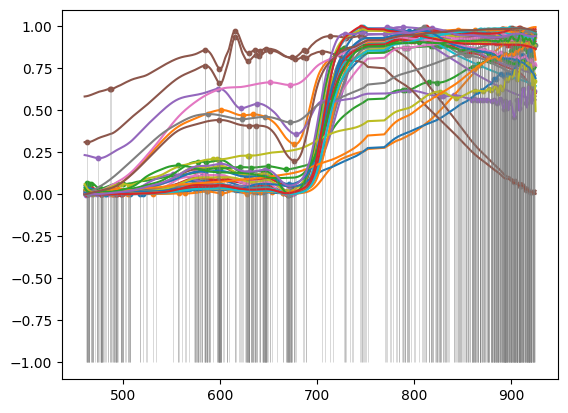

In [11]:
# Plot all the class means
for item in means.items():
    plt.plot(item[1].index, item[1])
    plt.vlines(x = features_dict[item[0]] , ymin= -1, ymax = item[1].loc[features_dict[item[0]]], linewidth = 0.7, alpha = 0.3, colors= "grey")

for item in means.items():
    plt.scatter(x = features_dict[item[0]], y = item[1].loc[features_dict[item[0]]], s = 10, label = item[0])
plt.savefig("profiles_and_features_.svg")

In [12]:
# Aggregate all filtered features into a single list 
features_list = [] 
for item in features_dict.items():
    features_list.append(list(item[1]))
features_list = [x for xs in features_list for x in xs]

In [27]:
print(len(np.unique(features_list)))
print(len(features_list))
print(len(features_list)/len(features_dict))
print(len(features_dict))

264
713
19.805555555555557
36


In [35]:
values, counts = np.unique(features_list, return_counts=True)
form = pd.DataFrame([values, counts])
form.to_csv("counts.csv")

In [14]:
# Inspect the agggregated features list
values, counts = np.unique(features_list, return_counts= True)
feature_counts = pd.DataFrame({"nm": values, "count": counts})
feature_counts.head()

,nm,count
0,461,1
1,462,5
2,463,4
3,464,2
4,465,3


In [15]:
# Make new reduced feature spectra sets
reduced_spectra = spectra_quiet.loc[:, list(feature_counts["nm"].astype("str"))]
reduced_spectra = reduced_spectra.transpose()
reduced_means = means.loc[feature_counts["nm"],:]

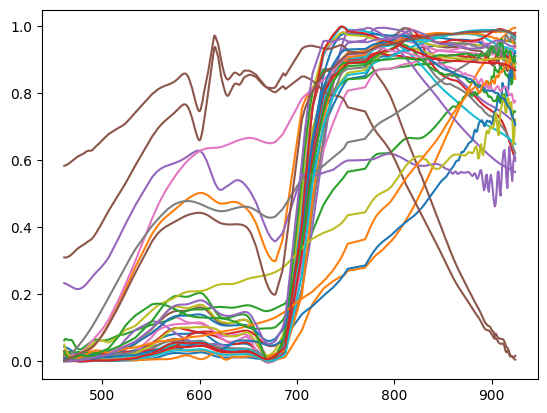

In [16]:
# Plot all reduced dimension class means
for col in reduced_means.columns:
    plt.plot(reduced_means.index, reduced_means.loc[:, col])
plt.show()

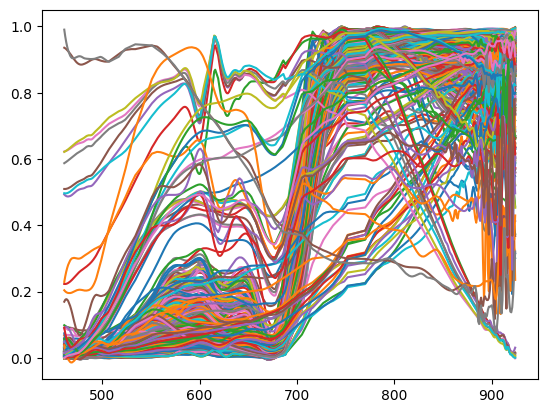

In [17]:
# Plot all reduced dimension spectra
for col in range(reduced_spectra.shape[1]):
    plt.plot(reduced_spectra.index.astype("int"), reduced_spectra.iloc[:, col])
plt.show()

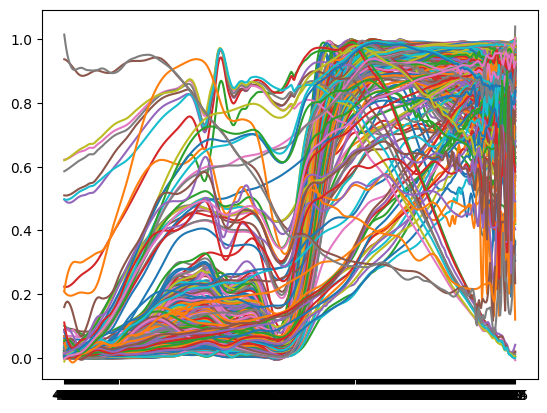

In [18]:
# Plot all denoised spectra
for row in range(spectra_quiet.shape[0]):
    plt.plot(spectra_quiet.columns, spectra_quiet.iloc[row, :])
plt.show()

In [19]:
# Format reduced, denoised spectra for MANOVA and ANOVA
reduced_spectra_labelled = pd.concat([labels_prepped[["Class", "site"]], reduced_spectra], axis = 1)

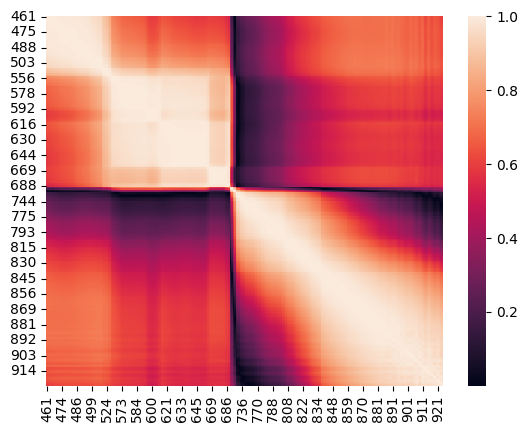

In [20]:
corr_mat = reduced_spectra.transpose().corr()
sns.heatmap(abs(corr_mat))
plt.savefig("correlation_matrix.svg")

In [21]:
# Filter features into groups by correlation threshold
# Then pick representative wavelength for that feature
features_id = []
start_nm = []
end_nm = []
i = 0
threshold = 0.98
corr_mat = abs(corr_mat)
for n in range(0, corr_mat.shape[0]):
    # check if any correlation below threshold in features i to n
    if any(np.sum(corr_mat.iloc[i:n, i:n] < threshold)):
        r = n-1
        # Find most representative feature as most correlated
        feat_num = np.argmax(np.sum(corr_mat.iloc[i:r, i:r], axis = 0)) + i
        features_id.append(int(corr_mat.index[feat_num]))
        print(f"Wavelength {corr_mat.index[feat_num]} identified as representative of {corr_mat.index[i]} to {corr_mat.index[r]}.")
        start_nm.append(int(corr_mat.index[i]))
        end_nm.append(int(corr_mat.index[r]))
        i = n
    else:                                                              
        ""

print(f"\n {len(features_id)} representative features found.")

Wavelength 473 identified as representative of 461 to 492.
Wavelength 500 identified as representative of 493 to 517.
Wavelength 524 identified as representative of 520 to 551.
Wavelength 578 identified as representative of 556 to 596.
Wavelength 604 identified as representative of 598 to 615.
Wavelength 632 identified as representative of 616 to 665.
Wavelength 672 identified as representative of 668 to 688.
Wavelength 705 identified as representative of 705 to 713.
Wavelength 716 identified as representative of 716 to 727.
Wavelength 734 identified as representative of 729 to 744.
Wavelength 752 identified as representative of 745 to 776.
Wavelength 789 identified as representative of 778 to 801.
Wavelength 812 identified as representative of 805 to 822.
Wavelength 828 identified as representative of 823 to 835.
Wavelength 844 identified as representative of 836 to 850.
Wavelength 859 identified as representative of 851 to 868.
Wavelength 877 identified as representative of 869 to 88

c:\Users\s4770224\Documents\GitHub\Spectral-Analysis\separability_venv\Lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


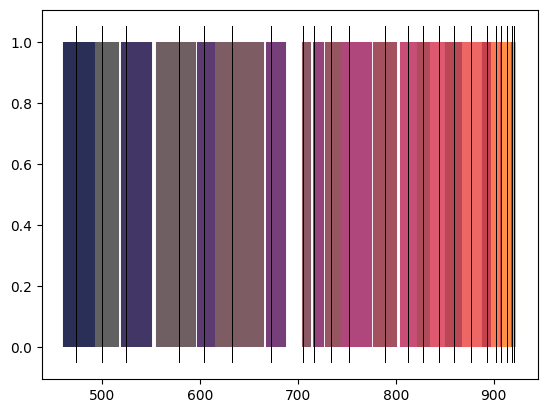

In [22]:
# Plot the feature ranges and the most representative bands chosen for analysis
colours_ordered = {
    1: "#292f56",
    2: "#413665",
    3: "#5b3b71",
    4: "#773f7a",
    5: "#94437d",
    6: "#af477d",
    7: "#c84e78",
    8: "#de586f",
    9: "#ef6764",
    10: "#fc7a56",
    11: "#ff9047",
    12: "#ffa836",
    13: "#fdc124", 
    14: "#f0db19",
    15: "#616161",
    16: "#6f5f63",
    17: "#7d5c63",
    18: "#8a5963",
    19: "#975561",
    20: "#a3515e",
    21: "#af4c59",
    22: "#ba4754",
    23: "#c5414e",
    24: "#cf3a46",
    25: "#d9333d",
    26: "#e12b33",
    27: "#e92228",
    28: "#f01919",}

colours_mixed = {
    1: "#292f56",
    2: "#616161",
    3: "#413665",
    4: "#6f5f63",
    5: "#5b3b71",
    6: "#7d5c63",
    7: "#773f7a",
    8: "#8a5963",
    9: "#94437d",
    10: "#975561",
    11: "#af477d",
    12: "#a3515e",
    13: "#c84e78",
    14: "#af4c59",
    15: "#de586f",
    16: "#ba4754",
    17: "#ef6764",
    18: "#c5414e",
    19: "#fc7a56",
    20: "#cf3a46",
    21: "#ff9047",
    22: "#d9333d",
    23: "#ffa836",
    24: "#e12b33",
    25: "#fdc124", 
    26: "#e92228",
    27: "#f0db19",
    28: "#f01919"}
    
counter= 1 
for a, b in zip (start_nm, end_nm):
    plt.vlines(x = list(range(a, b)), ymin = 0, ymax = 1, colors = colours_mixed[counter])
    counter +=1
for feature in features_id:
    plt.vlines(x = features_id, ymin = -0.05, ymax = 1.05, colors = 'black', linewidth = 0.7)
    plt.savefig("representative_features.svg")
plt.show()

In [23]:
# Make spectral data reduced to only representative features
features_id_str = [str(x) for x in features_id]
redred = spectra_prepped.loc[:, features_id_str]
redred.shape

(388, 23)

In [24]:
# Make data ingestible for MANOVA and ANOVA
comp_labels = labels_prepped["Class"] + "_" + labels_prepped["site"]
labels_array = comp_labels.astype('category').cat.codes.astype(float)

# MANOVA
maov = MANOVA(redred, labels_array) 
print(maov.mv_test())

#Access all digits in MANOVA results
maov_df = pd.DataFrame(maov.mv_test().results["x0"]["stat"])
maov_df.loc["Wilks' lambda", "Pr > F"]
for index in maov_df.index:
    print(maov_df.loc[index, "Pr > F"])

                  Multivariate linear model
                                                              
--------------------------------------------------------------
           x0           Value   Num DF  Den DF  F Value Pr > F
--------------------------------------------------------------
          Wilks' lambda 0.1930 23.0000 365.0000 66.3553 0.0000
         Pillai's trace 0.8070 23.0000 365.0000 66.3553 0.0000
 Hotelling-Lawley trace 4.1813 23.0000 365.0000 66.3553 0.0000
    Roy's greatest root 4.1813 23.0000 365.0000 66.3553 0.0000

2.8301400641098252e-115
2.8301400641096643e-115
2.8301400641096643e-115
2.8301400641096643e-115
